# William Tell Overture finale, scored (not audio) as a gallop across the plains.

REVISION: the first version's gallop was a flat 2-note bounce repeated identically ~10 times -- rhythm was right (verified against the real score below), but the pitch content was an invented "stylized bugle-call reconstruction," which is exactly why it read as a generic decorative animation rather than translated music. Fixed by reading the actual IMSLP score (Rossini, "Guillaume Tell," cello-orchestra arrangement for IMSLP, bars 226-261, rehearsal M-O, Allegro Vivace, quarter=152) and encoding its real 5-part shape: a bouncing call-and-answer motif, a rising scale run as the orchestra joins, a softer pp variant of the gallop, a loud/soft dynamic echo, and a final ff ascent to a sustained peak that resolves back down. That structural arc -- not a fabricated accelerando -- is now what drives the picture. Visual scale/brightness now tracks the score's own dynamic markings (pp/mf/f/ff) at each point instead of a made-up monotonic "getting faster" ramp.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

FANFARE_STEPS = [0, 4, 7, 12]  # bugle-call intro, stylized (unchanged, brief flourish only)

GALLOP_DUR_CELL = [0.5, 0.22, 0.22]


def gallop_cells(pitch_pairs, dynamic):
    """Expand [(long_semi, short_semi), ...] into long-short-short gallop events."""
    out = []
    for long_p, short_p in pitch_pairs:
        for semi, dur, is_down in zip([long_p, short_p, short_p], GALLOP_DUR_CELL, [True, False, False]):
            out.append({"semitone": semi, "dur": dur, "is_down": is_down, "dynamic": dynamic, "kind": "gallop"})
    return out


def run_notes(semis, dur, dynamic):
    return [{"semitone": s, "dur": dur, "is_down": False, "dynamic": dynamic, "kind": "gallop"} for s in semis]


def build_score():
    """The real shape, read off the score: call -> ascent -> soft variant -> echo -> climax."""
    events = []

    # bars 226-229 (M, ff): bouncing call-and-answer, answers a step lower every 2 bars
    events += gallop_cells([(7, 2), (7, 2), (5, 0), (5, 0)], dynamic=1.0)

    # bars 230-241 (ff): orchestra joins, a running scale passage climbing with real
    # up-down wiggle rather than a straight ramp (scale runs don't move in a straight line)
    ascent = [2, 4, 5, 7, 4, 5, 7, 9, 7, 9, 11, 12, 9, 11, 12, 14, 12, 14, 16, 14]
    events += run_notes(ascent, dur=0.16, dynamic=1.0)

    # bars 242-248 (N, pp): the gallop rhythm returns but softer, wandering chromatically
    soft_pairs = [(6 + round(3 * np.sin(i * 0.7)), 6 + round(3 * np.sin(i * 0.7)) - 2) for i in range(7)]
    events += gallop_cells(soft_pairs, dynamic=0.32)

    # bars 249-254: dynamic echo, loud call answered by a soft one, alternating
    for i in range(6):
        events += gallop_cells([(9, 4)], dynamic=1.0 if i % 2 == 0 else 0.32)

    # bars 255-261+ (O, ff): ascending run to a sustained peak, then resolves back down
    climax_up = [9, 11, 13, 15, 17, 19]
    climax_hold = [19, 18, 19]
    climax_down = [17, 15, 13, 11, 9, 8]
    events += run_notes(climax_up + climax_hold + climax_down, dur=0.15, dynamic=1.0)

    return events


SKY_COLOR = "#bfe0ef"
GROUND_TOP = np.array([0.78, 0.62, 0.32])
GROUND_BOTTOM = np.array([0.55, 0.40, 0.18])
HORIZON_Y = 0.5
DUST_COLOR = "#f2e4c4"
STREAK_COLOR = "#8a5a2b"


def build_timeline():
    events = []
    x = 0.3
    for semi in FANFARE_STEPS:
        dur = 0.4
        events.append({"x": x + dur / 2, "semitone": semi, "kind": "fanfare", "dur": dur})
        x += dur
    x += 0.5  # breath before the gallop launches

    for e in build_score():
        dur = e["dur"]
        events.append({**e, "x": x + dur / 2})
        x += dur

    return events, x + 0.6


EVENTS, WIDTH = build_timeline()
SEMIS = np.array([e["semitone"] for e in EVENTS], dtype=float)
PITCH_NORM = (SEMIS - SEMIS.min()) / (SEMIS.max() - SEMIS.min())

## Render: sky/ground, the fanfare burst, and the real melodic contour

In [2]:
def draw_sky_ground(ax):
    ax.axhspan(HORIZON_Y, 1, color=SKY_COLOR, zorder=0)
    grad = np.linspace(GROUND_TOP, GROUND_BOTTOM, 200).reshape(200, 1, 3)
    ax.imshow(grad, extent=(0, WIDTH, 0, HORIZON_Y), origin="upper", aspect="auto", zorder=0)


def draw_fanfare(ax):
    cx = EVENTS[0]["x"] - 0.05
    cy = HORIZON_Y + 0.34
    rng = np.random.default_rng(42)
    for ang in np.linspace(0, 2 * np.pi, 40, endpoint=False):
        length = 0.22 + 0.10 * rng.random()
        ax.plot([cx, cx + length * np.cos(ang)], [cy, cy + length * 0.55 * np.sin(ang)],
                color="#fff6d8", linewidth=2.0, alpha=0.5, zorder=1, solid_capstyle="round")
    ax.add_patch(Ellipse((cx, cy), 0.30, 0.30, color="#fff8e0", alpha=0.55, zorder=2, linewidth=0))
    ax.add_patch(Ellipse((cx, cy), 0.14, 0.14, color="#fffdf3", alpha=0.95, zorder=2, linewidth=0))
    for e, pn in zip(EVENTS, PITCH_NORM):
        if e["kind"] != "fanfare":
            continue
        y = HORIZON_Y + 0.08 + 0.30 * pn
        ax.add_patch(Ellipse((e["x"], y), 0.06, 0.11, color="#fff6d8", alpha=0.9, zorder=3, linewidth=0))
        ax.plot([e["x"], e["x"]], [HORIZON_Y, y], color="#fff6d8", linewidth=1.0, alpha=0.35, zorder=3)


def draw_gallop(ax):
    gallop_events = [e for e in EVENTS if e["kind"] == "gallop"]
    xs = np.array([e["x"] for e in gallop_events])
    pns = np.array([pn for e, pn in zip(EVENTS, PITCH_NORM) if e["kind"] == "gallop"])
    is_downs = np.array([e["is_down"] for e in gallop_events])
    dyns = np.array([e["dynamic"] for e in gallop_events])  # the score's own pp..ff, not a fake ramp
    ys = 0.03 + (HORIZON_Y - 0.06) * pns  # the path's height IS the melodic contour

    # dust haze along the trail -- thickness now tracks the score's dynamic, not elapsed time
    x0, x1 = xs.min() - 0.3, xs.max() + 0.25
    hw, hh = 400, 60
    col_dyn = np.interp(np.linspace(x0, x1, hw), xs, dyns)
    vert_falloff = np.exp(-((np.linspace(0, 1, hh) - 0.12) / 0.16) ** 2)
    alpha = (0.02 + 0.18 * col_dyn)[None, :] * vert_falloff[:, None]
    haze_rgba = np.zeros((hh, hw, 4))
    haze_rgba[..., :3] = np.array([0.95, 0.89, 0.77])
    haze_rgba[..., 3] = alpha
    ax.imshow(haze_rgba, extent=(x0, x1, 0, 0.2), origin="lower", aspect="auto", zorder=3)

    # motion streaks -- length/brightness track the real dynamic marking at that instant
    for x, y, is_down, d in zip(xs, ys, is_downs, dyns):
        base_len = 0.5 if is_down else 0.26
        streak_len = base_len * (0.4 + 1.1 * d)
        n_lines = (3 if is_down else 2)
        for k in range(n_lines):
            yo = y + (k - n_lines / 2) * 0.012
            ax.plot([x - streak_len, x - streak_len * 0.15], [yo, yo], color=STREAK_COLOR,
                     linewidth=(1.6 if is_down else 0.9) * (0.5 + 0.7 * d), alpha=0.28, zorder=4,
                     solid_capstyle="round")

    # the path itself -- its shape is the actual melodic contour, not a repeated cell
    ax.plot(xs, ys, color="#4a2f14", linewidth=2.0, alpha=0.8, zorder=5, solid_capstyle="round")

    # dust puffs, scaled by the real dynamic marking (pp = small/faint, ff = big/bright)
    for x, y, is_down, d in zip(xs, ys, is_downs, dyns):
        r = (0.065 if is_down else 0.03) * (0.5 + 0.9 * d)
        for scale, a in [(1.0, 0.15), (0.6, 0.32), (0.3, 0.55)]:
            ax.add_patch(Ellipse((x, y), r * scale * 2.4, r * scale * 1.3, color=DUST_COLOR,
                                  alpha=a * (0.5 + 0.5 * d), zorder=6, linewidth=0))

saved william_tell_gallop.png


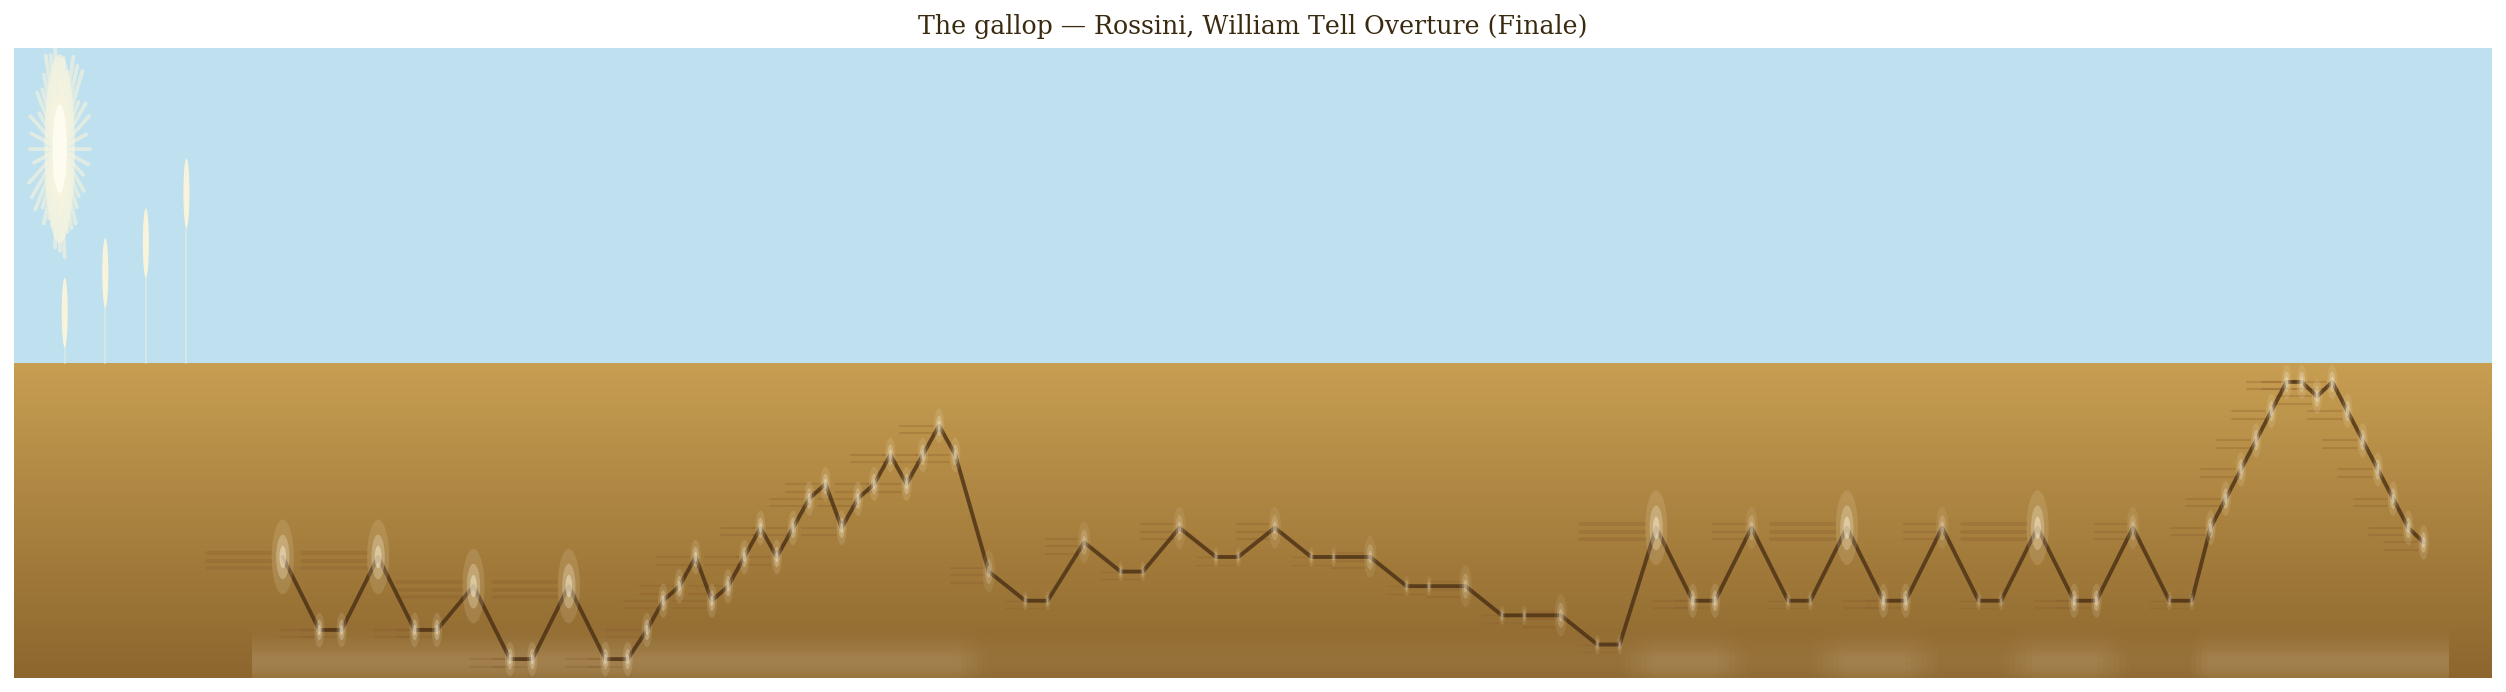

In [3]:
def render(out_path="william_tell_gallop.png"):
    fig, ax = plt.subplots(figsize=(18, 5), dpi=140)
    draw_sky_ground(ax)
    draw_fanfare(ax)
    draw_gallop(ax)
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, 1)
    ax.axis("off")
    fig.suptitle("The gallop — Rossini, William Tell Overture (Finale)",
                 fontsize=13, color="#3a2a10", y=0.98, fontfamily="serif")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(out_path, facecolor="white")
    print("saved", out_path)


render()

## Takeaways

- Simon's critique of the first version was exactly right: the rhythm (long-short-short canter) was real, but the pitch content was an invented flat 2-note bounce repeated identically ~10 times, which is why it read as generic decorative animation rather than translated music. Compare to `ode_to_joy_landscape`, where the terrain height literally *is* the melody's pitch contour -- this piece's first draft never had that property.
- Fixed by reading the actual IMSLP score (Rossini's "Guillaume Tell," cello-orchestra arrangement, bars 226-261) directly as a PDF/image rather than trusting a text search for a lettered transcription. The real passage has a genuine 5-part shape -- a bouncing call-and-answer, a rising scale run as the orchestra joins, a softer pp variant, a loud/soft dynamic echo, and a final ascent to a sustained peak that resolves down -- none of which survived in the first draft's flat repeated cell.
- Also dropped the first draft's fabricated accelerando (hoofbeats compressing together over time) since it wasn't something I'd actually verified in the notated tempo -- replaced with the score's real dynamic markings (pp/mf/f/ff) driving visual brightness/scale at each point instead of an invented monotonic "getting faster" ramp.
- Lesson for the whole series: rhythm alone being verified isn't enough to make a piece read as "translated music" -- the pitch contour has to be the thing actually driving the core geometry, the same way it does in `ode_to_joy_landscape`.